# DESN Real-Time ENSO Forecast

Pipeline:
1. **Data loading** — full 1958–2026 dataset; train/val split
2. **Hyperparameter configuration**
3. **Hyperparameter tuning** *(optional, skipped by default)*
4. **Train on 1979–2020**
5. **Member selection + skill comparison** vs XRO on both validation sets
6. **Real-time rolling forecast** from the latest time point

In [11]:
import warnings
warnings.filterwarnings("ignore")
from RCENSO import *
from XRO import *
import numpy as np
import reservoirpy as rpy
import xarray as xr
rpy.verbosity(0)
%config InlineBackend.figure_format = 'retina'

# ── Global settings ──────────────────────────────────────────────────────────
SKIP_TUNING = True          # Set False to enable hyperparameter tuning
TUNE_RECENT_WEIGHT = 0.5    # Weight of val(recent) in tuning score; past weight = 1 - this
FORECAST_STEPS = 21         # Real-time forecast horizon (months)
REALTIME_START = '2026-03-01'  # Latest initialisation month
PLOT_MODE = 'Nino34'        # Climate mode to plot in the real-time forecast figure
NMEMBERS = 5                # Ensemble members (increase for better estimates)

climate_modes = ['Nino34', 'WWV', 'NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']

## 1. Data Loading

Three temporal splits:
- **Training**: 1979–2020  
- **Val (past)**: 1958–1978 (pre-training hindcast period)  
- **Val (recent)**: 2021–2026 (out-of-sample)

In [12]:
# Load full dataset 1958–2026
ds_full = xr.open_dataset('oras5_indices_1958-2026.nc', engine='netcdf4')
ds_full = standardize_time_to_month_start(ds_full)
ds_full = ds_full[['Nino34', 'WWV'] + [v for v in ds_full.data_vars if v not in ('Nino34', 'WWV')]]

# Training dataset (1979–2020) — used to build the full TS matrix
train_ds = ds_full.sel(time=slice('1979-01-01', '2020-12-01'))

# Validation datasets
val_past_ds  = ds_full.sel(time=slice('1958-01-01', '1978-12-01'))
val_recent_ds = ds_full.sel(time=slice('2021-01-01', '2026-12-01'))

# TS matrix for the training window only (used to train models)
TS_train = train_ds.to_array().values.T          # (T_train, n_vars)
tl = TS_train.shape[0]                           # training length

# TS matrices for validation windows
TS_past   = val_past_ds.to_array().values.T
TS_recent = val_recent_ds.to_array().values.T

print(f"Training length : {tl} months  ({train_ds.time.values[0]} – {train_ds.time.values[-1]})")
print(f"Val (past)      : {TS_past.shape[0]} months")
print(f"Val (recent)    : {TS_recent.shape[0]} months")

Training length : 504 months  (1979-01-01T00:00:00.000000000 – 2020-12-01T00:00:00.000000000)
Val (past)      : 252 months
Val (recent)    : 63 months


## 2. Hyperparameter Configuration

Default hyperparameters (from the paper).  
The tuning cell below will update these if `SKIP_TUNING = False`.

In [13]:
model_types = [r'DESN($n_l=1$)', r'DESN($n_l=2$)']

hypers = {
    model_types[0]: {
        'units': 20000,
        'lr': 1,
        'sr': 1,
        'rc_connectivity': 0.0,
        'input_connectivity': 0.10,
        'input_scaling': 1,
        'ridge': 5e-6,
        'noise_rc': 0.05,
        'noise_in': 0,
        'output_dim': TS_train.shape[1],
        'seed': None,
        'use_raw_input': True,
        'ip_reservoir': True,
    },
    model_types[1]: {
        'units': [20000, 12000],
        'lr': [1, 1],
        'sr': [1, 1],
        'rc_connectivity': [0, 0],
        'input_connectivity': [0.1, 0.1],
        'input_scaling': [1, 1],
        'ridge': 5e-6,
        'noise_rc': [0.05, 0],
        'noise_in': [0, 0],
        'output_dim': TS_train.shape[1],
        'seed': None,
        'deep': True,
        'deep_ip_list': [True, False],
    },
}

print("Default hyperparameters loaded.")

Default hyperparameters loaded.


## 3. Hyperparameter Tuning *(optional)*

**Strategy**: layer-by-layer, using a **Genetic Algorithm** for fine-tuning around the default values.

- **Layer 1**: GA optimises `input_connectivity` ∈ [0.05, 0.20], `noise_rc` ∈ [0.01, 0.10], `ridge` ∈ [5e-7, 5e-5] (log-scale).
- **Layer 2** (built on best L1): GA optimises `input_connectivity_L2` ∈ [0.05, 0.20] and `units_L2` ∈ [6000, 20000].

GA settings (`GA_POP`, `GA_GENS`, `GA_ELITE`, `GA_MUT_SIGMA`) are tunable at the top of the cell.  
Objective = weighted Nino34 corr at lead 1–12 across both validation sets (`TUNE_RECENT_WEIGHT`).  
Set `SKIP_TUNING = True` (top cell) to skip entirely.

In [14]:
def _val_corr_nino34(trained_models, steps=20, tp_order=2):
    """Weighted mean Nino34 corr (lead 1–12) across both validation sets.
    TUNE_RECENT_WEIGHT controls the weight of val(recent); past weight = 1 - it.
    """
    w_recent = TUNE_RECENT_WEIGHT
    w_past   = 1.0 - w_recent
    scores = []
    for TS_val, w in [(TS_past, w_past), (TS_recent, w_recent)]:
        if w == 0:
            continue
        TP_val = get_RCTP(TS_val, steps=steps, omega=2*np.pi/12, order=tp_order, bias=0)
        Ypred_mean, _ = TPRC_Forecast_Ensemble(
            trained_models, TS_val, TP_test=TP_val, steps=steps, noise_ini=0.0)
        Ytest_arr = np.hstack((TS_val, TP_val[:-steps]))
        R, _ = ndforecast_skill(Ypred_mean, Ytest_arr, showdim=0, ismv3=True, wl=0)
        scores.append(w * np.mean(R[1:13]))
    return sum(scores)


# ── Genetic Algorithm fine-tuning ─────────────────────────────────────────────
# Each gene is a float in [0, 1] that linearly maps to the parameter's search
# range. Ranges are narrow, centred on the default values (±perturbation only).

GA_POP   = 12    # population size (keep small: each eval = 1 training run)
GA_GENS  = 8     # number of generations
GA_ELITE = 2     # elite individuals carried forward unchanged
GA_MUT_SIGMA = 0.15   # Gaussian mutation std (in gene space [0,1])
GA_CROSS_PROB = 0.6   # crossover probability per gene
GA_SEED  = 42


def _decode_l1(gene):
    """Map gene vector [0,1]^3 → (input_connectivity, noise_rc, ridge).
    Ranges: ±50% around defaults, log-scale for ridge.
    """
    ic    = 0.05  + gene[0] * 0.15          # [0.05, 0.20]
    noise = 0.01  + gene[1] * 0.09          # [0.01, 0.10]
    # ridge in log-space: default 5e-6, range [5e-7, 5e-5]
    ridge = 10 ** (-6.3 + gene[2] * 2.0)   # ≈ [5e-7, 5e-5]
    return ic, noise, ridge


def _decode_l2(gene, best_l1):
    """Map gene vector [0,1]^2 → (input_connectivity_l2, units_l2)."""
    ic2 = 0.05 + gene[0] * 0.15            # [0.05, 0.20]
    u2  = int(round((6000 + gene[1] * 14000) / 1000) * 1000)  # [6k,20k] step 1k
    u2  = min(u2, 20000)
    return ic2, u2


def _ga_evolve(n_genes, decode_fn, eval_fn, pop_size, n_gens,
               n_elite, mut_sigma, cross_prob, rng, label):
    """Minimalist GA: real-valued genes in [0,1]^n_genes.
    Uses tournament selection, uniform crossover, Gaussian mutation.
    Returns best_gene, best_score.
    """
    pop = rng.uniform(0, 1, size=(pop_size, n_genes))
    fitness = np.full(pop_size, -np.inf)

    for gen in range(n_gens):
        # Evaluate unevaluated individuals
        for i in range(pop_size):
            if fitness[i] == -np.inf:
                fitness[i] = eval_fn(pop[i])

        best_idx = np.argmax(fitness)
        print(f"  [{label}] Gen {gen+1}/{n_gens}  "
              f"best={fitness[best_idx]:.4f}  params={decode_fn(pop[best_idx])}")

        if gen == n_gens - 1:
            break

        # Sort by fitness descending
        order = np.argsort(fitness)[::-1]
        new_pop = pop[order[:n_elite]].copy()  # elites
        new_fit = fitness[order[:n_elite]].copy()

        # Fill rest of population via tournament + crossover + mutation
        while len(new_pop) < pop_size:
            # Tournament selection (size 3)
            def tournament():
                idx = rng.choice(pop_size, size=3, replace=False)
                return pop[idx[np.argmax(fitness[idx])]].copy()

            p1, p2 = tournament(), tournament()
            # Uniform crossover
            mask = rng.uniform(size=n_genes) < cross_prob
            child = np.where(mask, p1, p2)
            # Gaussian mutation
            child += rng.normal(0, mut_sigma, size=n_genes)
            child = np.clip(child, 0, 1)
            new_pop = np.vstack([new_pop, child[None]])
            new_fit = np.append(new_fit, -np.inf)  # will be evaluated next gen

        pop = new_pop
        fitness = new_fit

    best_idx = np.argmax(fitness)
    return pop[best_idx], fitness[best_idx]


if not SKIP_TUNING:
    rng = np.random.default_rng(GA_SEED)

    # ── Layer 1 GA ────────────────────────────────────────────────────────────
    print("=" * 60)
    print(f"LAYER 1 GA TUNING  "
          f"(recent_w={TUNE_RECENT_WEIGHT}, pop={GA_POP}, gens={GA_GENS})")
    print("=" * 60)

    def _eval_l1(gene):
        ic, noise, ridge = _decode_l1(gene)
        h = {**hypers[model_types[0]],
             'input_connectivity': ic, 'noise_rc': noise, 'ridge': ridge}
        models_tmp, _ = TPRC_Train_Ensemble(TS_train, tl, dl=0, hypers=h, nmember=1)
        return _val_corr_nino34(models_tmp)

    best_gene_l1, best_score_l1 = _ga_evolve(
        n_genes=3, decode_fn=_decode_l1, eval_fn=_eval_l1,
        pop_size=GA_POP, n_gens=GA_GENS, n_elite=GA_ELITE,
        mut_sigma=GA_MUT_SIGMA, cross_prob=GA_CROSS_PROB,
        rng=rng, label='L1')

    ic_best, noise_best, ridge_best = _decode_l1(best_gene_l1)
    best_l1_params = {'input_connectivity': ic_best,
                      'noise_rc': noise_best, 'ridge': ridge_best}
    hypers[model_types[0]].update(best_l1_params)
    print(f"\nBest L1: ic={ic_best:.4f}, noise={noise_best:.4f}, "
          f"ridge={ridge_best:.2e}  (score={best_score_l1:.4f})")

    # ── Layer 2 GA ────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"LAYER 2 GA TUNING  (pop={GA_POP}, gens={GA_GENS})")
    print("=" * 60)

    def _eval_l2(gene):
        ic2, u2 = _decode_l2(gene, best_l1_params)
        h2 = {**hypers[model_types[1]],
              'input_connectivity': [ic_best, ic2],
              'noise_rc': [noise_best, 0],
              'ridge': ridge_best,
              'units': [20000, u2]}
        models_tmp2, _ = TPRC_Train_Ensemble(TS_train, tl, dl=0, hypers=h2, nmember=1)
        return _val_corr_nino34(models_tmp2)

    best_gene_l2, best_score_l2 = _ga_evolve(
        n_genes=2, decode_fn=lambda g: _decode_l2(g, best_l1_params),
        eval_fn=_eval_l2,
        pop_size=GA_POP, n_gens=GA_GENS, n_elite=GA_ELITE,
        mut_sigma=GA_MUT_SIGMA, cross_prob=GA_CROSS_PROB,
        rng=rng, label='L2')

    ic2_best, u2_best = _decode_l2(best_gene_l2, best_l1_params)
    hypers[model_types[1]].update({
        'input_connectivity': [ic_best, ic2_best],
        'noise_rc': [noise_best, 0],
        'ridge': ridge_best,
        'units': [20000, u2_best],
    })
    print(f"\nBest L2: ic2={ic2_best:.4f}, units2={u2_best}  (score={best_score_l2:.4f})")

else:
    print("Hyperparameter tuning skipped (SKIP_TUNING=True).")

Hyperparameter tuning skipped (SKIP_TUNING=True).


## 4. Train DESN Ensemble on 1979–2020

In [15]:
trained_models = {}   # {model_type: list_of_esns}
TP_train = {}         # {model_type: TP array}

for mt in model_types:
    print(f"Training {mt} …")
    models, tp = TPRC_Train_Ensemble(
        TS_train, tl, dl=0, hypers=hypers[mt], nmember=NMEMBERS)
    trained_models[mt] = models
    TP_train[mt] = tp
    print(f"  Done. ({NMEMBERS} member(s))")

Training DESN($n_l=1$) …


Training ensemble members: 100%|██████████| 5/5 [02:57<00:00, 35.46s/it]


  Done. (5 member(s))
Training DESN($n_l=2$) …


Training ensemble members:   0%|          | 0/5 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


...

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members:  80%|████████  | 4/5 [13:39<02:59, 179.19s/it]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 5/5 [15:29<00:00, 185.94s/it]

  Done. (5 member(s))


## 5. Validation, Member Selection & Skill Comparison

- **Member selection**: from all `NMEMBERS × 2` trained models (both architectures), greedily pick the best `N_SELECT` whose *joint* ensemble mean maximises the weighted validation score.
- **Skill plot**: selected DESN ensemble vs XRO baseline on both validation sets.

Forecasting with ensemble: 100%|██████████| 5/5 [01:58<00:00, 23.70s/it]


Pool: 10 members | Exhaustive search: 848 combinations (k=4..10)
  k= 4  best=0.7903  members=(5, 6, 8, 9)  (DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k= 5  best=0.7833  members=(5, 6, 7, 8, 9)  (DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#2, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k= 6  best=0.7763  members=(0, 5, 6, 7, 8, 9)  (DESN(n_l=1)#0, DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#2, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k= 7  best=0.7672  members=(0, 4, 5, 6, 7, 8, 9)  (DESN(n_l=1)#0, DESN(n_l=1)#4, DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#2, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k= 8  best=0.7592  members=(0, 1, 4, 5, 6, 7, 8, 9)  (DESN(n_l=1)#0, DESN(n_l=1)#1, DESN(n_l=1)#4, DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#2, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k= 9  best=0.7520  members=(0, 1, 3, 4, 5, 6, 7, 8, 9)  (DESN(n_l=1)#0, DESN(n_l=1)#1, DESN(n_l=1)#3, DESN(n_l=1)#4, DESN(n_l=2)#0, DESN(n_l=2)#1, DESN(n_l=2)#2, DESN(n_l=2)#3, DESN(n_l=2)#4)
  k=10  best=0.7451  members=(0, 1, 2, 3,

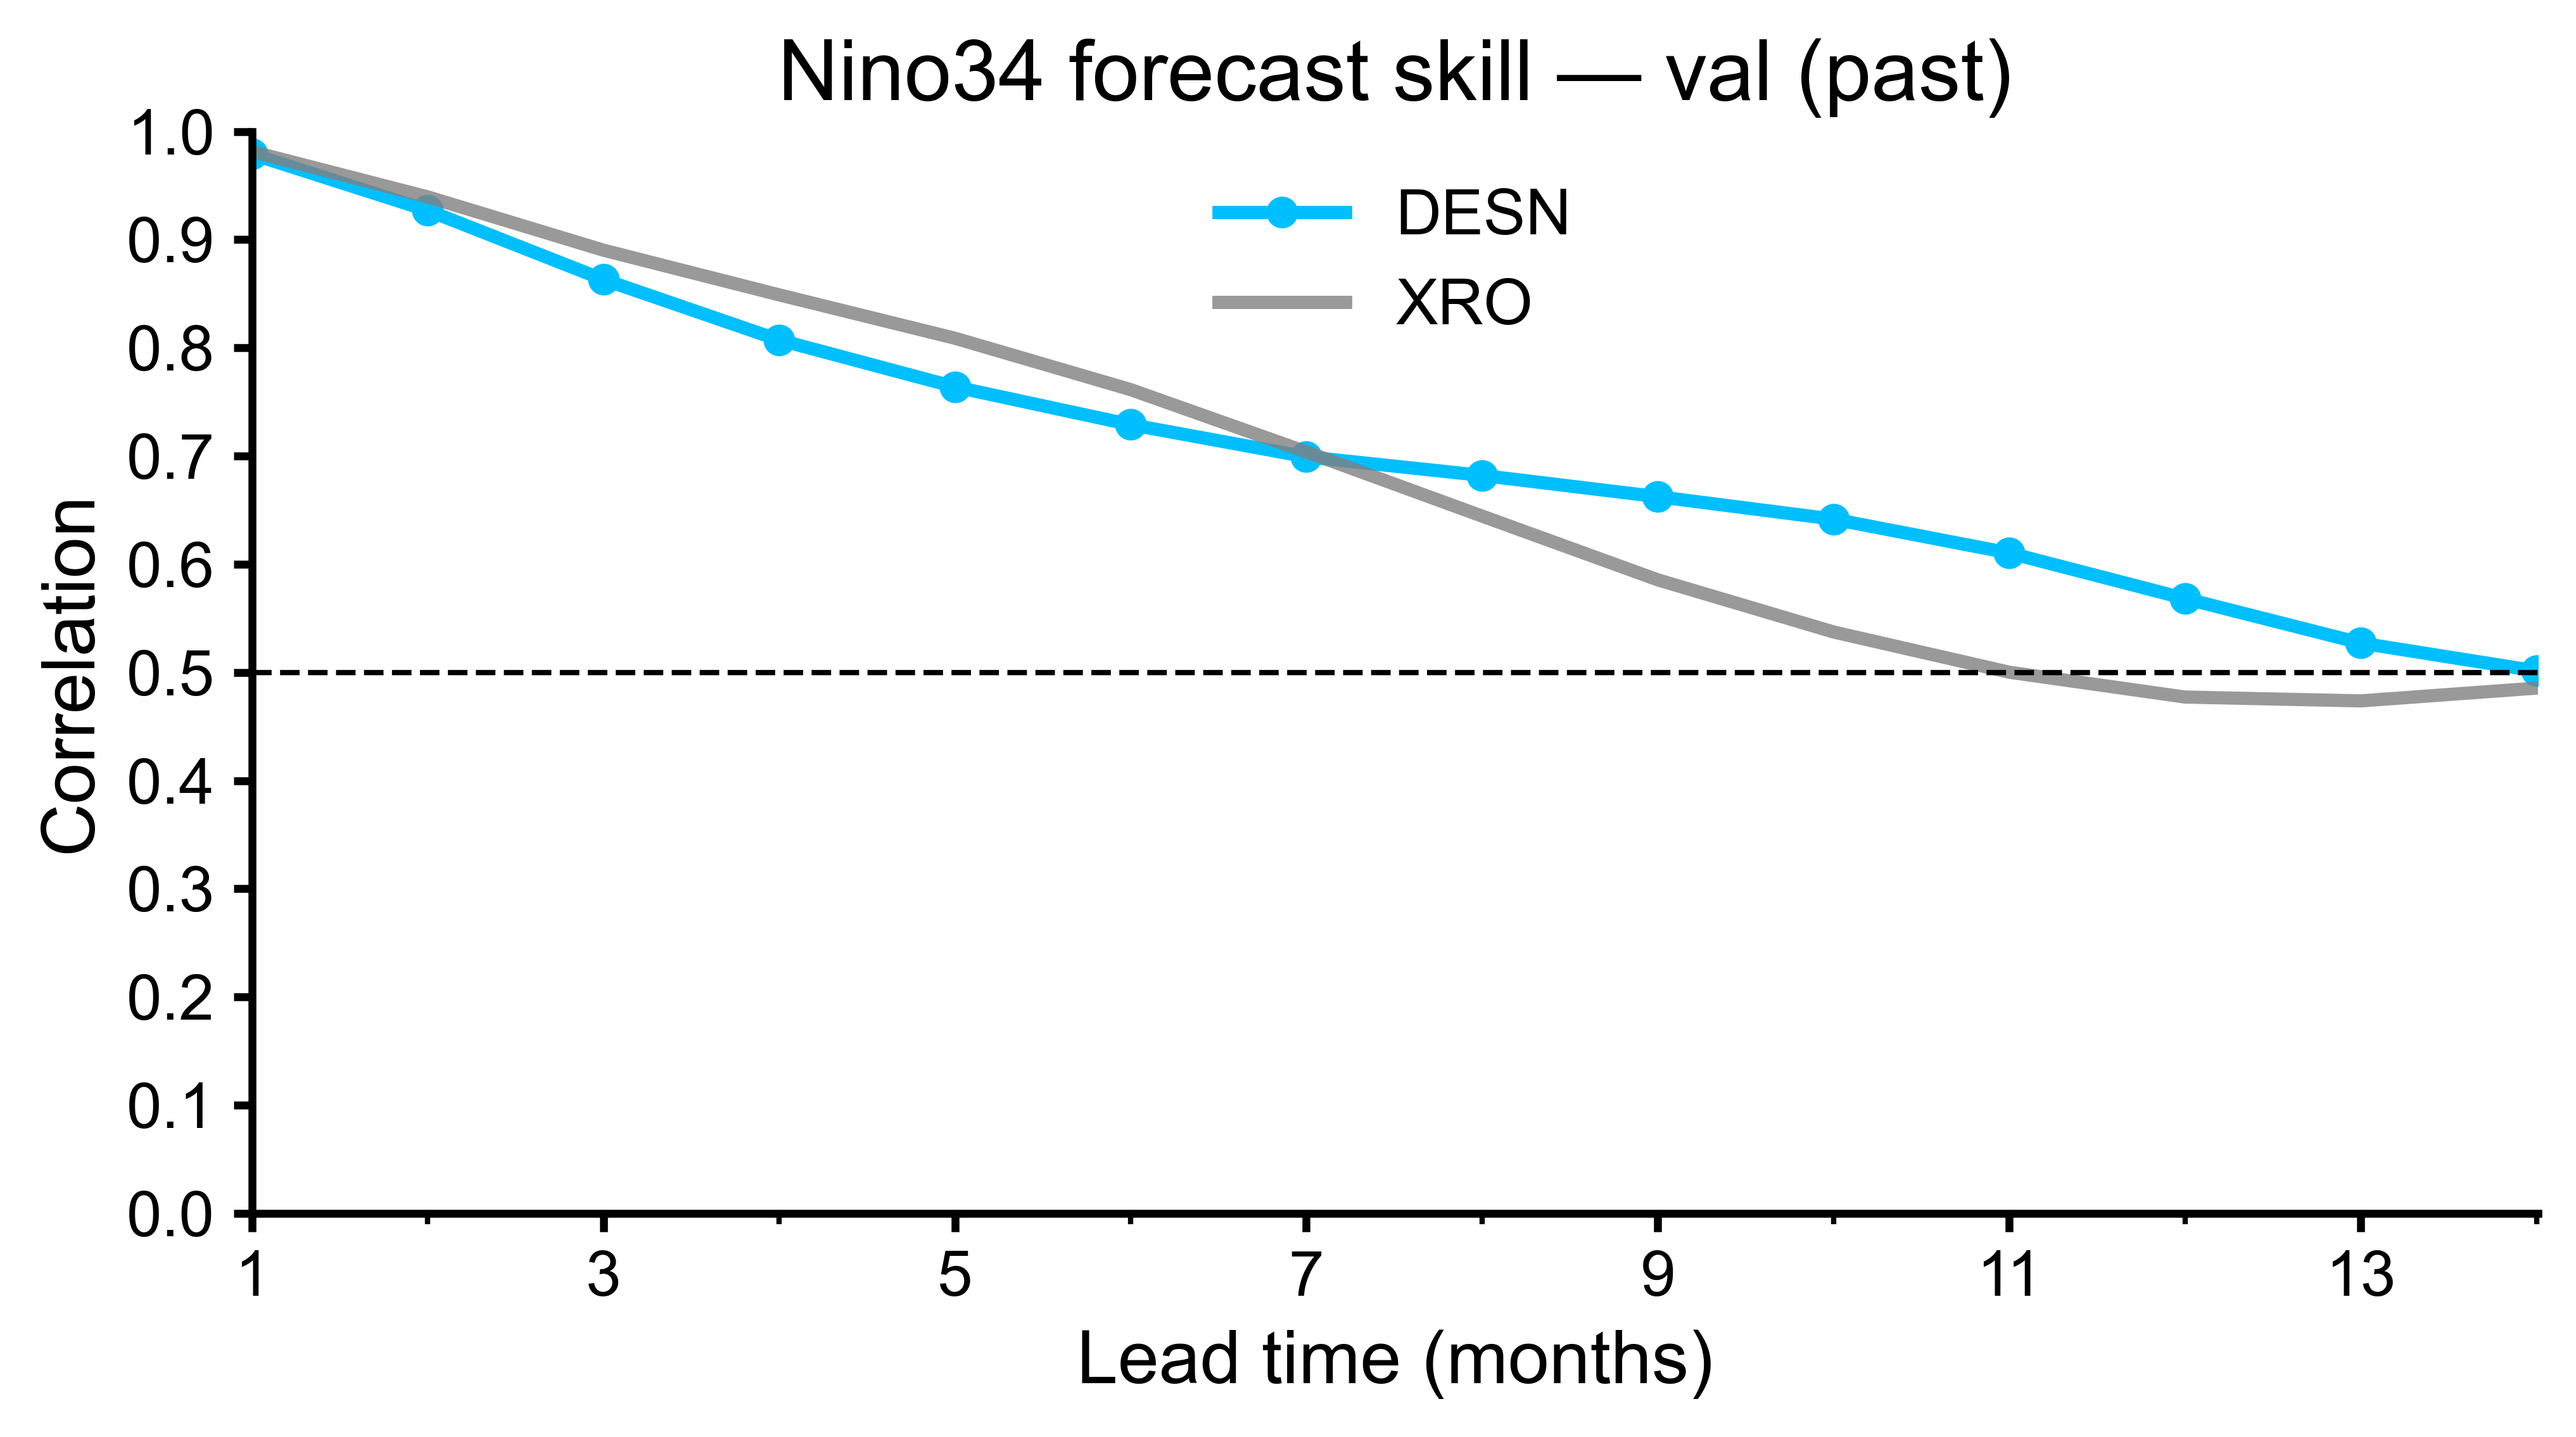

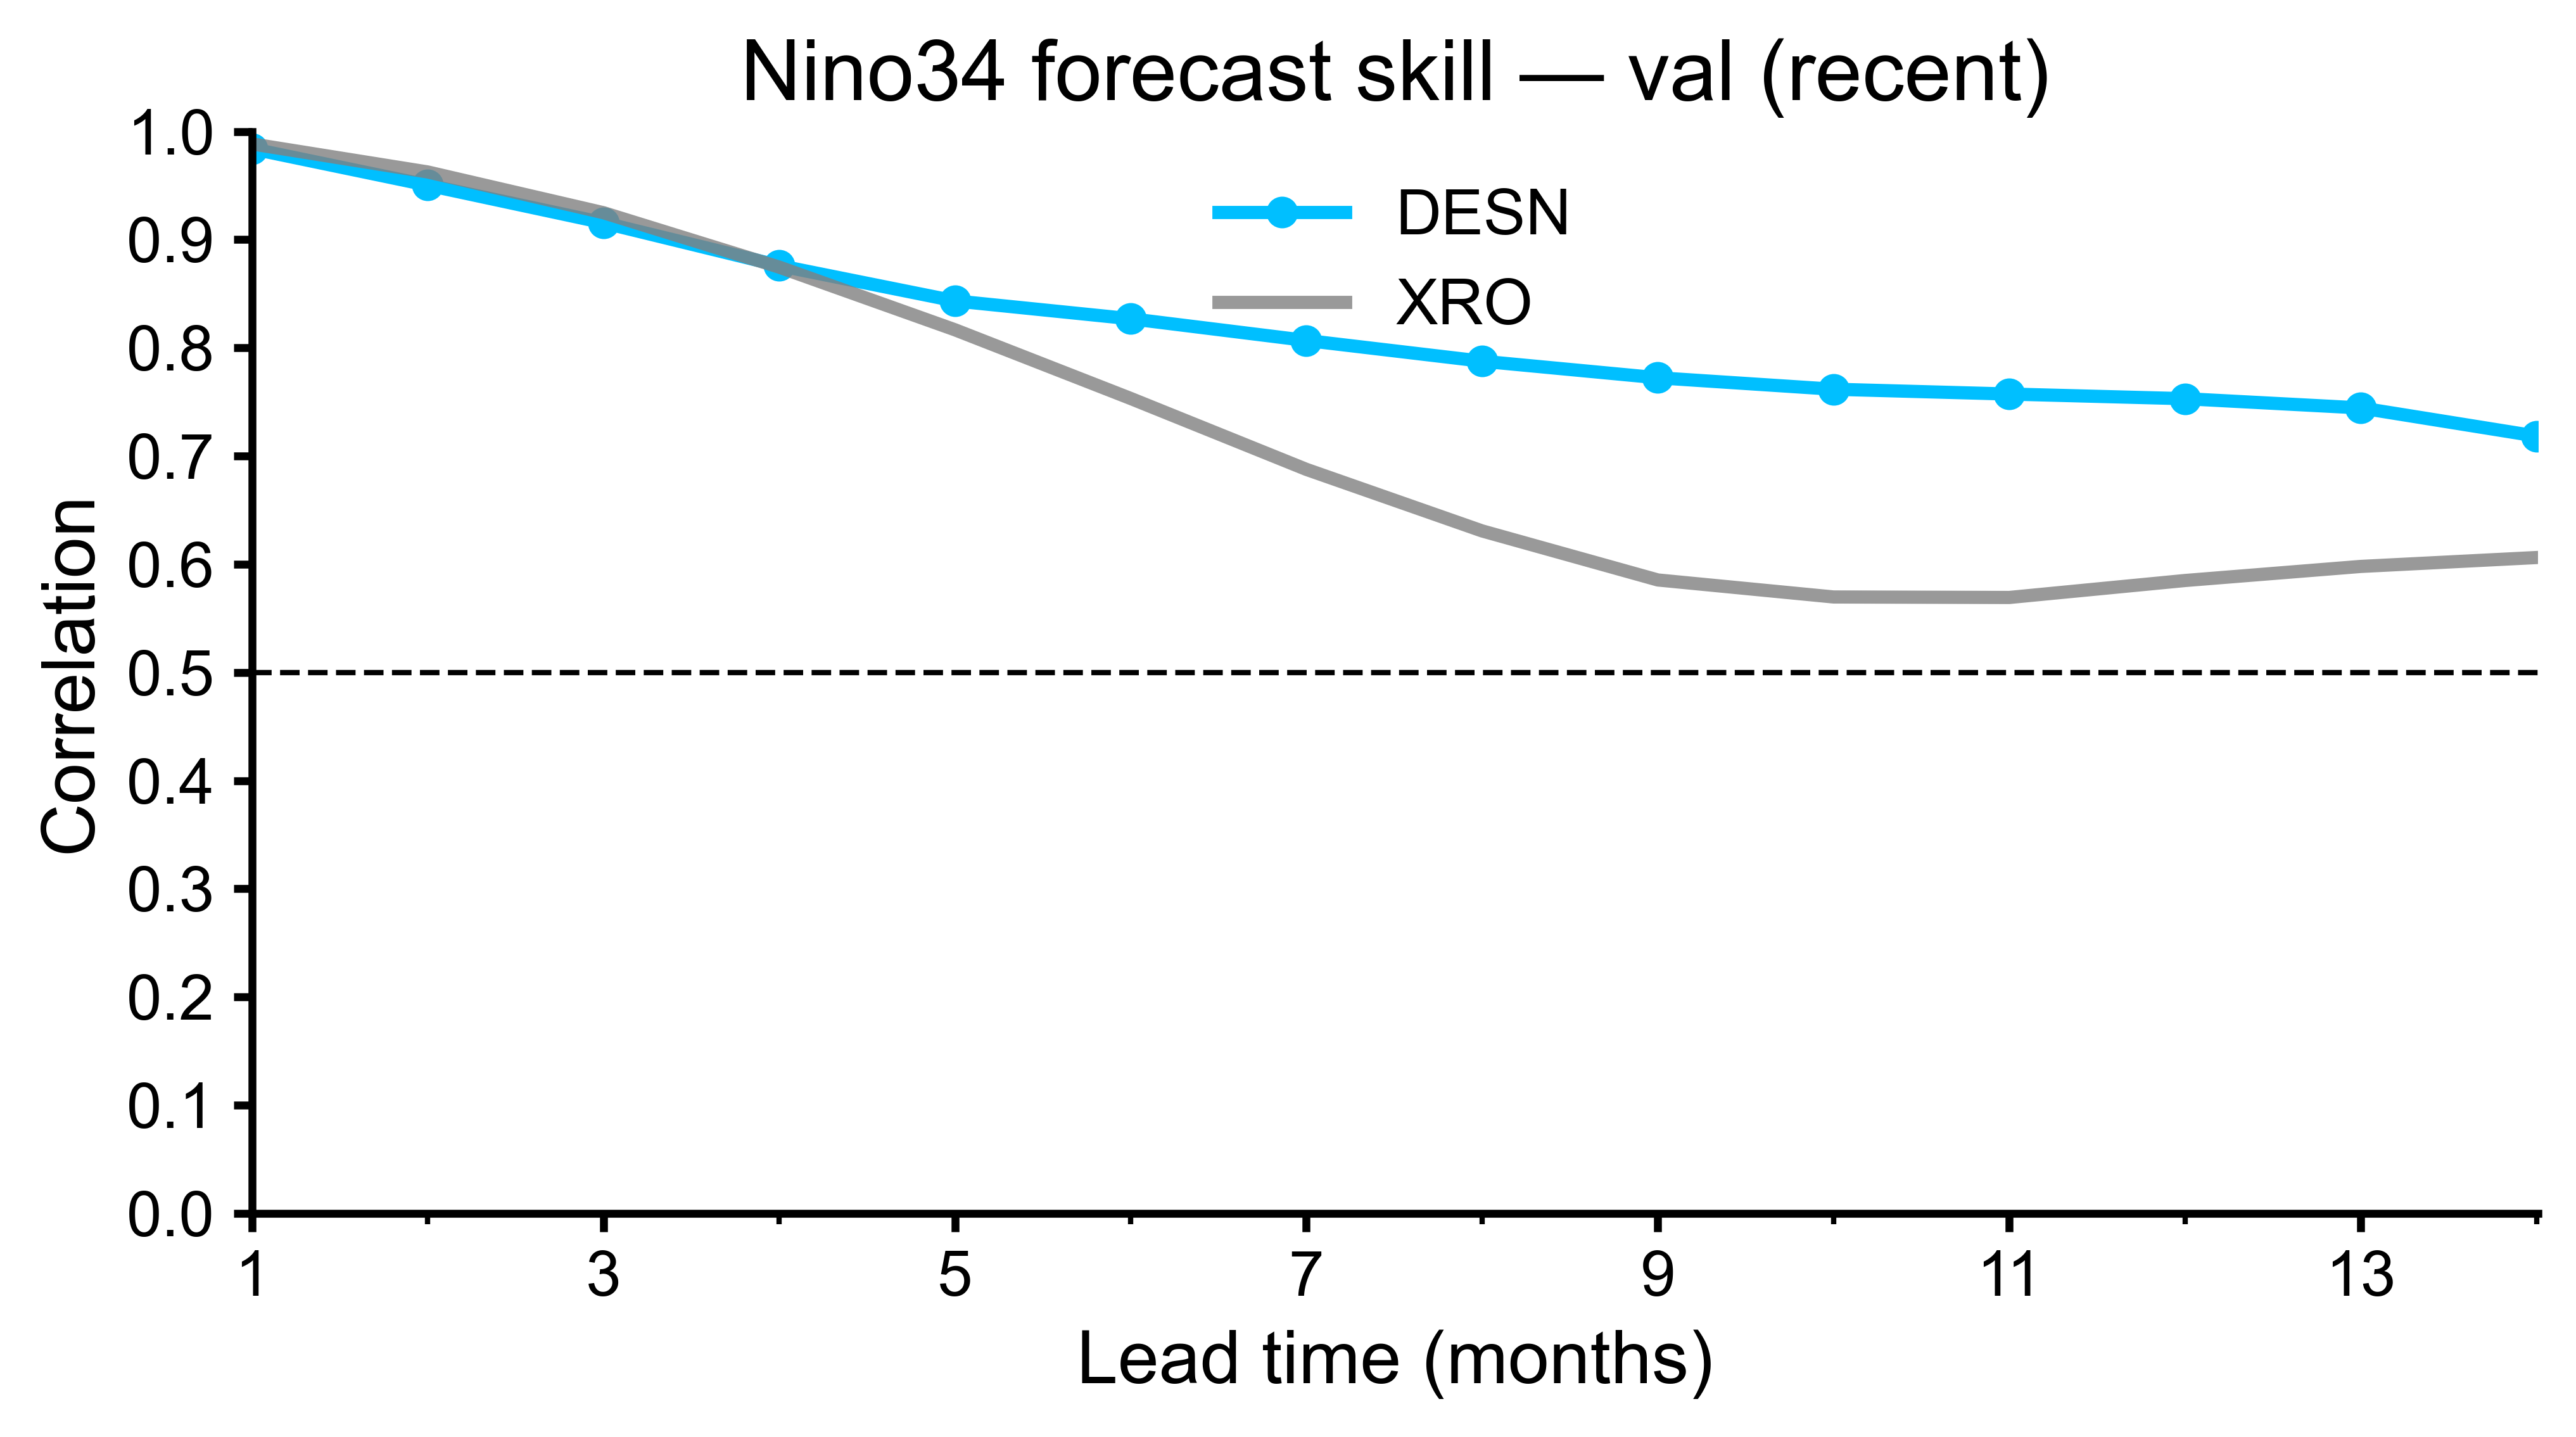

In [33]:
from itertools import combinations
from math import comb

KEEP_SELECT = 4          # minimum ensemble size
KEEP_MAX    = 10         # maximum ensemble size (full pool)
FORECAST_STEPS_SKILL = 15   # lead times for skill evaluation


# ── Gather predictions from all members on both validation sets ─────────────
all_member_preds = {}    # {val_label: list of (T, n_vars+tp, steps) arrays}
Ytest_val = {}

for val_label, TS_val in [('past', TS_past), ('recent', TS_recent)]:
    TP_val = get_RCTP(TS_val, steps=FORECAST_STEPS_SKILL,
                      omega=2*np.pi/12, order=2, bias=0)
    Ytest_val[val_label] = np.hstack((TS_val, TP_val[:-FORECAST_STEPS_SKILL]))
    
    preds_list = []
    for mt in model_types:
        _, preds_mt = TPRC_Forecast_Ensemble(
            trained_models[mt], TS_val, TP_test=TP_val,
            steps=FORECAST_STEPS_SKILL, noise_ini=0.0)
        for m in range(preds_mt.shape[0]):
            preds_list.append(preds_mt[m])
    all_member_preds[val_label] = preds_list

n_pool = len(all_member_preds['past'])
total = sum(comb(n_pool, k) for k in range(KEEP_SELECT, KEEP_MAX + 1))
print(f"Pool: {n_pool} members | Exhaustive search: {total} combinations (k={KEEP_SELECT}..{KEEP_MAX})")

# ── Scoring function for any subset ─────────────────────────────────────────
def score_subset(indices):
    score = 0.0
    for val_label, w in [('past', 1 - TUNE_RECENT_WEIGHT), ('recent', TUNE_RECENT_WEIGHT)]:
        if w == 0:
            continue
        ens = np.mean([all_member_preds[val_label][i] for i in indices], axis=0)
        R, _ = ndforecast_skill(ens, Ytest_val[val_label], showdim=0, ismv3=True, wl=0)
        score += w * np.mean(R[1:13])
    return score

# ── Exhaustive search: C(n,4) to C(n,10) ────────────────────────────────────
best_score = -np.inf
best_combo = None
best_size  = None

for k in range(KEEP_SELECT, KEEP_MAX + 1):
    best_k, score_k = None, -np.inf
    for combo in combinations(range(n_pool), k):
        s = score_subset(list(combo))
        if s > score_k:
            score_k, best_k = s, combo
    
    # print per-size summary
    names = [f"{model_types[i//max(1,NMEMBERS)].replace('$','')}#{i%max(1,NMEMBERS)}" for i in best_k]
    print(f"  k={k:2d}  best={score_k:.4f}  members={best_k}  ({', '.join(names)})")
    
    if score_k > best_score:
        best_score, best_combo, best_size = score_k, best_k, k

selected = list(best_combo)
print(f"\n>> Global best: size={best_size}, score={best_score:.4f}, members={selected}")

# ── Build selected model list (compatible with downstream code) ─────────────
selected_models = []
for idx in selected:
    mt = model_types[idx // max(1, NMEMBERS)]
    selected_models.append({
        'arch': mt,
        'member': idx % max(1, NMEMBERS),
        'esn': trained_models[mt][idx % max(1, NMEMBERS)]
    })

# ── Evaluate selected ensemble vs XRO baseline ────────────────────────────────
corr_desn, corr_xro = {}, {}

XROac2 = XRO(ncycle=12, ac_order=2)
XROac2_fit = XROac2.fit_matrix(train_ds, maskb=['Nino34', 'IOD'])

for val_label, TS_val, val_ds in [('past', TS_past, val_past_ds),
                                  ('recent', TS_recent, val_recent_ds)]:
    # DESN ensemble mean
    ens = np.mean([all_member_preds[val_label][i] for i in selected], axis=0)
    R_desn, _ = ndforecast_skill(ens, Ytest_val[val_label], showdim=0, ismv3=True, wl=0)
    corr_desn[val_label] = R_desn

    # XRO baseline
    xro = XROac2.reforecast(fit_ds=XROac2_fit, init_ds=val_ds,
                            n_month=FORECAST_STEPS_SKILL - 1, ncopy=1, noise_type='zero')
    Ypred = xro.to_array().values.transpose(1, 0, 2)
    n_steps = Ypred.shape[2]
    TP_xro = get_RCTP(TS_val, steps=n_steps, omega=2*np.pi/12, order=2, bias=0)
    Ytest_xro = np.hstack((TS_val, TP_xro[:-n_steps]))
    R_xro, _ = ndforecast_skill(Ypred, Ytest_xro, showdim=0, ismv3=True, wl=0)
    corr_xro[val_label] = R_xro

    print(f"{val_label:8s}  DESN@6={R_desn[6]:.3f}  XRO@6={R_xro[6]:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
styles = {
    'DESN': {'color': 'deepskyblue', 'marker': 'o', 'linewidth': 2.5, 'markersize': 5},
    'XRO':  {'color': 'gray',        'marker': '',  'linewidth': 2.5, 'alpha': 0.8},
}
for val_label in ['past', 'recent']:
    plot_main_skills_with_legend(
        skill_dict={'DESN': corr_desn[val_label], 'XRO': corr_xro[val_label]},
        styles=styles, grid_on=False, legend=True, legend_in_main=True,
        figsize=(7, 4), ylim=(0.0, 1.0), xlim=(1, FORECAST_STEPS_SKILL - 0.99),
        skill_name='Correlation',
        title=f'{PLOT_MODE} forecast skill — val ({val_label})',
    )

## 6. Real-Time Rolling Forecast from Latest Time Point

In [35]:
def realtime_forecast(models, x0, TP_rt, t0, forecast_steps):
    """
    Iterative multi-step real-time forecast for a given model ensemble.

    Parameters
    ----------
    models : list of dict
        Selected model list, each item must contain key 'esn' with a .run() method.
        e.g. [{'arch': 'DESN$', 'member': 0, 'esn': esn_obj}, ...]
    x0 : ndarray, shape (n_vars,)
        Latest observed state (initial condition).
    TP_rt : ndarray, shape (T_full + forecast_steps, n_tp)
        RCTP (known external forcing) covering history + forecast leads.
    t0 : int
        Time index of the last observed month in TP_rt (i.e. len(history)).
    forecast_steps : int
        Number of lead months to predict.

    Returns
    -------
    member_preds : ndarray, shape (n_models, forecast_steps + 1, n_vars)
        Individual forecasts. Lead 0 is the observed x0; leads 1..forecast_steps
        are model predictions.
    ens_mean : ndarray, shape (forecast_steps + 1, n_vars)
        Ensemble mean across all models.
    ens_std : ndarray, shape (forecast_steps + 1, n_vars)
        Ensemble standard deviation.
    """
    member_preds = []

    for model in models:
        esn = model['esn']
        fcst = [x0.copy()]                     # lead 0 = observation

        # Reservoir input: [state, RCTP] at t0-1 (last observed time)
        rctp = TP_rt[t0 - 1, :].reshape(1, -1)
        x = np.hstack((x0.reshape(1, -1), rctp))

        for j in range(1, forecast_steps + 1):
            y = esn.run(x)                     # (1, n_vars)
            fcst.append(y[0].copy())

            # Advance to next lead's known RCTP
            rctp = TP_rt[t0 - 1 + j, :].reshape(1, -1)
            x = np.hstack((y, rctp))

        member_preds.append(np.array(fcst))    # (forecast_steps+1, n_vars)

    member_preds = np.array(member_preds)      # (n_models, forecast_steps+1, n_vars)
    ens_mean = member_preds.mean(axis=0)
    ens_std  = member_preds.std(axis=0)

    return member_preds, ens_mean, ens_std

In [40]:
# --- prepare history & forcing ------------------------------------------------
ds_full_to_latest = ds_full.sel(time=slice('1979-01-01', REALTIME_START))
TS_full = ds_full_to_latest.to_array().values.T          # (T, n_vars)
t0      = TS_full.shape[0]
x0      = TS_full[-1, :].copy()                        # (n_vars,)

TP_rt = get_RCTP(TS_full, steps=FORECAST_STEPS,
                 omega=2*np.pi/12, order=2, bias=0)    # (T+steps, n_tp)

# --- call the unified forecast function ----------------------------------------
member_preds, rt_mean, rt_std = realtime_forecast(
    selected_models, x0, TP_rt, t0, FORECAST_STEPS
)

start_pd = pd.Timestamp(REALTIME_START)
forecast_times = pd.date_range(start_pd, periods=FORECAST_STEPS + 1, freq='MS')
print(f'forecast from {forecast_times[0]} to {forecast_times[-1]}')

forecast from 2026-03-01 00:00:00 to 2027-12-01 00:00:00


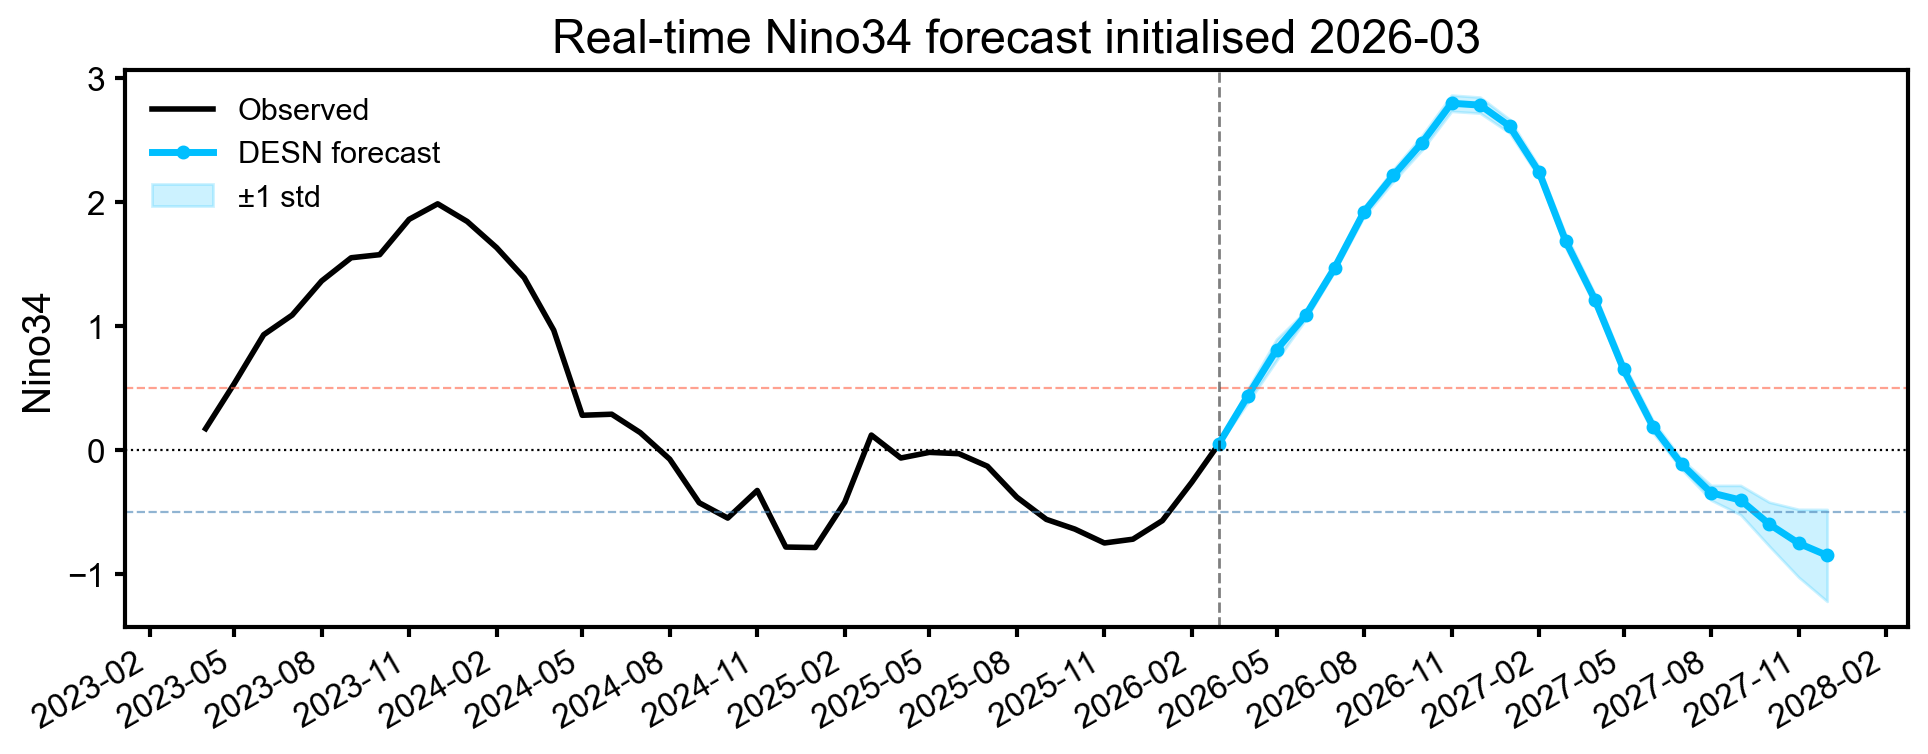

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Resolve mode index from the dataset itself ─────────────────────────────────
mode_idx = list(ds_full.data_vars).index(PLOT_MODE)

# ── Historical observed (last 36 months before forecast) ─────────────────────
n_hist = 36
time_full = ds_full_to_latest.time.values
hist_times = pd.DatetimeIndex([pd.Timestamp(str(t)[:10]) for t in time_full[-n_hist:]])
hist_vals  = TS_full[-n_hist:, mode_idx]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Observed history
ax.plot(hist_times, hist_vals, color='black', linewidth=2, label='Observed')

# DESN ensemble mean forecast (lead 0 = obs, leads 1..N = forecast)
ax.plot(forecast_times, rt_mean[:, mode_idx],
        color='deepskyblue', linewidth=2.5, marker='o', markersize=4,
        label='DESN forecast')

# Ensemble spread (±1 std) — check actual ensemble size, not raw NMEMBERS
if member_preds.shape[0] > 1:
    ax.fill_between(
        forecast_times,
        rt_mean[:, mode_idx] - rt_std[:, mode_idx],
        rt_mean[:, mode_idx] + rt_std[:, mode_idx],
        color='deepskyblue', alpha=0.2, label='±1 std')

# XRO real-time forecast
# ds_init_rt = ds_full.sel(time=REALTIME_START).expand_dims('time')
# try:
#     xro_rt_fcst = XROac2.reforecast(
#         fit_ds=XROac2_fit, init_ds=ds_init_rt,
#         n_month=FORECAST_STEPS, ncopy=1, noise_type='zero')
#     xro_rt_vals = xro_rt_fcst[PLOT_MODE].values.squeeze()  # (steps,)
#     xro_times = pd.date_range(start_pd, periods=len(xro_rt_vals), freq='MS')
#     ax.plot(xro_times, xro_rt_vals,
#             color='gray', linewidth=2, linestyle='--', label='XRO forecast')
# except Exception as e:
#     print(f"XRO real-time forecast skipped: {e}")

# ── Decorations ─────────────────────────────────────────────────────────────
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axhline(0.5,  color='tomato',     linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(-0.5, color='steelblue',  linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(start_pd, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.set_ylabel(PLOT_MODE)
ax.set_title(f'Real-time {PLOT_MODE} forecast initialised {REALTIME_START[:7]}')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Save Models & Forecast Data

In [45]:
import os, pickle
import pandas as pd
import xarray as xr

SAVE_DIR = f'desn_forecast_{REALTIME_START[:7]}'
os.makedirs(SAVE_DIR, exist_ok=True)

n_selected = len(selected)
n_pool     = len(model_types) * NMEMBERS

# ── 1. Save ALL models with selection flags ───────────────────────────────────
all_models_meta = []
for mt in model_types:
    for m in range(NMEMBERS):
        pool_idx = model_types.index(mt) * NMEMBERS + m
        all_models_meta.append({
            'arch': mt,
            'member': m,
            'pool_idx': pool_idx,
            'selected': pool_idx in selected,
        })

with open(os.path.join(SAVE_DIR, 'all_models_meta.pkl'), 'wb') as f:
    pickle.dump({
        'all_models_meta': all_models_meta,
        'selected_pool_indices': selected,
        'selected_models': selected_models,
        'n_pool': n_pool,
        'n_selected': n_selected,
        'KEEP_SELECT': KEEP_SELECT,
    }, f)
print(f"Saved all-model metadata + selected ESNs ({n_selected}/{n_pool}) → "
      f"{SAVE_DIR}/all_models_meta.pkl")

# ── 2. Save forecast data (selected-ensemble only) ──────────────────────────
fc_times  = pd.date_range(REALTIME_START, periods=FORECAST_STEPS + 1, freq='MS')
sel_arr   = np.arange(n_selected)

# Skill arrays may have different length than FORECAST_STEPS — use local coords
skill_lead_past   = np.arange(len(corr_desn['past']))
skill_lead_recent = np.arange(len(corr_desn['recent']))

ds_fc = xr.Dataset(
    {
        'forecast_mean': xr.DataArray(
            rt_mean,
            dims=['time', 'mode'],
            attrs={'description': f'Ensemble mean of {n_selected} selected members',
                   'units': 'std'}),

        'forecast_std': xr.DataArray(
            rt_std,
            dims=['time', 'mode'],
            attrs={'description': f'Ensemble std of {n_selected} selected members',
                   'units': 'std'}),

        'forecast_members': xr.DataArray(
            member_preds,
            dims=['member', 'time', 'mode'],
            attrs={'description': 'Per-member forecasts (selected members only)',
                   'selected_pool_indices': str(selected),
                   'units': 'std'}),

        # Validation skill — each carries its own lead coordinate locally
        'nino34_skill_corr_past': xr.DataArray(
            corr_desn['past'],
            dims=['lead'],
            coords={'lead': skill_lead_past},
            attrs={'description': 'Nino34 Pearson corr (val past)',
                   'val_period': '1958-1978'}),

        'nino34_skill_corr_recent': xr.DataArray(
            corr_desn['recent'],
            dims=['lead'],
            coords={'lead': skill_lead_recent},
            attrs={'description': 'Nino34 Pearson corr (val recent)',
                   'val_period': '2021-2026'}),

        'nino34_skill_corr_xro_past': xr.DataArray(
            corr_xro['past'],
            dims=['lead'],
            coords={'lead': skill_lead_past},
            attrs={'description': 'Nino34 XRO baseline corr (val past)','val_period': '1958-1978'}),

        'nino34_skill_corr_xro_recent': xr.DataArray(
            corr_xro['recent'],
            dims=['lead'],
            coords={'lead': skill_lead_recent},
            attrs={'description': 'Nino34 XRO baseline corr (val recent)','val_period': '2021-2026'}),
    },
    coords={
        'time':   fc_times.values,
        'mode':   climate_modes,
        'member': sel_arr,
    },
    attrs={
        'title': 'DESN real-time ENSO forecast',
        'init_month': REALTIME_START[:7],
        'train_period': '1979-2020',
        'n_pool_total': int(n_pool),
        'n_members_selected': int(n_selected),
        'selected_pool_indices': str(selected),
        'TUNE_RECENT_WEIGHT': TUNE_RECENT_WEIGHT,
    }
)

nc_path = os.path.join(SAVE_DIR, f'desn_forecast_{REALTIME_START[:7]}.nc')
ds_fc.to_netcdf(nc_path)
print(f"Saved forecast .nc → {nc_path}")
print(ds_fc)

Saved all-model metadata + selected ESNs (4/10) → desn_forecast_2026-03/all_models_meta.pkl
Saved forecast .nc → desn_forecast_2026-03\desn_forecast_2026-03.nc
<xarray.Dataset> Size: 12kB
Dimensions:                       (time: 22, mode: 10, member: 4, lead: 15)
Coordinates:
  * time                          (time) datetime64[ns] 176B 2026-03-01 ... 2...
  * mode                          (mode) <U6 240B 'Nino34' 'WWV' ... 'SASD'
  * member                        (member) int32 16B 0 1 2 3
  * lead                          (lead) int32 60B 0 1 2 3 4 ... 10 11 12 13 14
Data variables:
    forecast_mean                 (time, mode) float64 2kB 0.04602 ... -0.5882
    forecast_std                  (time, mode) float64 2kB 0.0 0.0 ... 0.1415
    forecast_members              (member, time, mode) float64 7kB 0.04602 .....
    nino34_skill_corr_past        (lead) float64 120B 1.0 0.979 ... 0.5013
    nino34_skill_corr_recent      (lead) float64 120B 1.0 0.984 ... 0.7184
    nino34_skill_corr